#Trabajo de Sandra Blázquez Arriero

## Insertar los datos:

Lo primero que tenemos que hacer es insertar los datos con los que vamos a trabajar, en mi caso voy a insertarlos desde mi portatil, es decir, de manera local, porque es donde tengo los datos.

Para hacerlo al ejecutar este comando, nos saldrá un botón de elegir archivos, y con ese elegimos los archivos que tenemos en el portatil.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving datos.zip to datos.zip


Ahora, como tenemos un archivo .zip, tenemos que extraer los archivos del zip.

In [3]:
import zipfile
import os

zip_file = 'datos.zip'

extract_path = 'extracted_files'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Archivos extraídos:")
print(os.listdir(extract_path))

Archivos extraídos:
['Data']


Vamos a ver todo lo que tenemos dentro de la carpeta para ver también donde se encuentran todos los archivos que vamos a tener que utilizar.

In [4]:
import os

data_directory = 'extracted_files/Data'

def listar_archivos(directorio):
    archivos = []
    for root, dirs, files in os.walk(directorio):
        for file in files:
            archivos.append(os.path.join(root, file))
    return archivos

# Mostrar los archivos
archivos_en_data = listar_archivos(data_directory)
for archivo in archivos_en_data:
    print(archivo)

extracted_files/Data/readme.txt
extracted_files/Data/channels.csv
extracted_files/Data/NBack/NBack_18.csv
extracted_files/Data/NBack/NBack_17.csv
extracted_files/Data/NBack/EEG_12.csv
extracted_files/Data/NBack/EEG_17.csv
extracted_files/Data/NBack/EEG_1.csv
extracted_files/Data/NBack/EEG_4.csv
extracted_files/Data/NBack/EEG_15.csv
extracted_files/Data/NBack/EEG_6.csv
extracted_files/Data/NBack/EEG_10.csv
extracted_files/Data/NBack/NBack_14.csv
extracted_files/Data/NBack/EEG_11.csv
extracted_files/Data/NBack/NBack_15.csv
extracted_files/Data/NBack/NBack_5.csv
extracted_files/Data/NBack/EEG_5.csv
extracted_files/Data/NBack/NBack_6.csv
extracted_files/Data/NBack/EEG_8.csv
extracted_files/Data/NBack/NBack_4.csv
extracted_files/Data/NBack/NBack_12.csv
extracted_files/Data/NBack/NBack_7.csv
extracted_files/Data/NBack/NBack_2.csv
extracted_files/Data/NBack/EEG_9.csv
extracted_files/Data/NBack/EEG_3.csv
extracted_files/Data/NBack/NBack_19.csv
extracted_files/Data/NBack/NBack_9.csv
extracted_f

## Cambio nombre en columnas:

Ahora, como en el archivo de EEG tenemos nombres no significativos, tenemos que reemplazar los nombres de las columnas de esos que teniamos a los que tenemos en el archivo "channels.csv" que son más significativos, los reescribimos y los guardamos en una nueva carpeta dentro de la anterior.

In [5]:
import pandas as pd
import os

channels_path = 'extracted_files/Data/channels.csv'
input_directory = 'extracted_files/Data/NBack'
output_directory = 'renamed_EEG_files'
os.makedirs(output_directory, exist_ok=True)

channels_df = pd.read_csv(channels_path)
channel_names = channels_df.columns.tolist()

eeg_files = [f for f in os.listdir(input_directory) if f.startswith('EEG') and f.endswith('.csv')]

for eeg_file in eeg_files:
    eeg_path = os.path.join(input_directory, eeg_file)
    eeg_df = pd.read_csv(eeg_path)

    for i in range(16):
        old_col = f'EEG{i}'
        if old_col in eeg_df.columns:
            eeg_df.rename(columns={old_col: channel_names[i]}, inplace=True)

    eeg_df.to_csv(os.path.join(output_directory, eeg_file), index=False)

print("Todos los archivos EEG renombrados y guardados en 'renamed_EEG_files'")

Todos los archivos EEG renombrados y guardados en 'renamed_EEG_files'


## Combinar los datos:

Ahora, como tenemos 19 archivos distintos tanto de NBack como de EEG, tenemos que unir todos pero de una manera particular.

Lo que tenemos que hacer es, unir los archivos que coincidan con el numero (ejemplo NBack_1 con EEG_1 y así con todos).
Después de eso tenemos que ver el valor de la columna Time del archivo NBack correspondiente, ese time será con el cual elegiremos con cual de los EEG empezamos, por ejemplo, si es 17.92353 el time de NBack, entonces los valores de EEG con los que tenemos que trabajar seran los que tengan un Time igual o mayor a ese que tiene el NBack.

Cuando tengamos eso, separamos por bloques, y esto lo hacemos por el Event Code del NBack, el event code nos indica que, cuando sea 1, empieza el bloque, y ese acaba cuando el event code sea 2, y así con todos los bloques que se tengan por cada archivo (que en total creo que son 3 por cada uno)

Una vez tengamos eso con quedamos con los valores correspondientes unicamente a esos dos, el inicio y el fin del bloque, el resto los ignoramos.

Y eso es lo que hemos realizado en el código que vemos despues, tenemos las rutas de los archivos, y los canales que queremos del eeg, cogemos con el for los archicos que tenemos, que son del 1 al 19 y vamos cogiendo los valores necesarias para el data frame, esto, para ser mas sencillo lo dividimos en el inicio (event code 1) y fin (event code 2) y al finalizar los metemos todos en un data frame.

In [6]:
import pandas as pd
import os

eeg_dir = 'renamed_EEG_files'
nback_dir = 'extracted_files/Data/NBack'

filas_df = []

canales_eeg = ['F4','Oz','Fz','F8','Pz','F5','T5','T3','C4','C3','T4','P4','T6','Cz','P3','F7']

for s in range(1, 20):
    eeg_path = os.path.join(eeg_dir, f'EEG_{s}.csv')
    events_path = os.path.join(nback_dir, f'NBack_{s}.csv')

    try:
        eeg_df = pd.read_csv(eeg_path)
        events_df = pd.read_csv(events_path)

        eeg_df['Time'] = eeg_df['Time'].astype(float)
        events_df['Time'] = events_df['Time'].astype(float)

        # Buscar eventos de inicio y fin
        event_starts = events_df[events_df['Event Code'] == 1].index.tolist()
        event_ends = events_df[events_df['Event Code'] == 2].index.tolist()

        if len(event_starts) != len(event_ends):
            print(f"⚠️ Participante {s}: Eventos desbalanceados. Saltando.")
            continue

        for i, (start_idx, end_idx) in enumerate(zip(event_starts, event_ends)):
            start_time = events_df.loc[start_idx, 'Time']
            end_time = events_df.loc[end_idx, 'Time']

            eeg_start_idx = eeg_df[eeg_df['Time'] >= start_time].index.min()
            eeg_end_idx = eeg_df[eeg_df['Time'] <= end_time].index.max()

            # Fila de inicio
            fila_inicio = {
                'participante': s,
                'bloque': i + 1,
                'time eeg': eeg_df.loc[eeg_start_idx, 'Time'],
                'Notes': events_df.loc[start_idx, 'Notes'],
            }
            for canal in canales_eeg:
                fila_inicio[canal] = eeg_df.loc[eeg_start_idx, canal]

            # Fila de fin
            fila_fin = {
                'participante': s,
                'bloque': i + 1,
                'time eeg': eeg_df.loc[eeg_end_idx, 'Time'],
                'Notes': events_df.loc[end_idx, 'Notes'],
            }
            for canal in canales_eeg:
                fila_fin[canal] = eeg_df.loc[eeg_end_idx, canal]

            # Agregar ambas filas
            filas_df.append(fila_inicio)
            filas_df.append(fila_fin)

    except Exception as e:
        print(f"❌ Error en participante {s}: {e}")

df_eeg_notas = pd.DataFrame(filas_df)

print(df_eeg_notas.head())

   participante  bloque    time eeg  Notes           F4            Oz  \
0             1       1   17.924878    1.0  2314.685302  14760.401830   
1             1       1   95.025437    1.0  2576.716653  15532.527367   
2             1       2  108.525945    2.0  2500.425194  15013.976631   
3             1       2  185.556188    2.0  2913.494166  15412.432199   
4             1       3  229.417213    3.0  2606.150312  14439.880360   

             Fz            F8           Pz            F5            T5  \
0  19244.003426  15623.870267  3445.551045  17231.466371  23761.431219   
1  19172.019331  15483.868747  4255.092250  17107.051671  24047.870970   
2  19179.977005  15343.636041  3925.724864  17055.351127  23662.313161   
3  19354.705131  15609.816577  4206.105102  17189.195792  23774.122127   
4  18870.601146  15113.155528  3682.504773  16834.629107  23393.577409   

            T3            C4            C3            T4            P4  \
0  8791.939687  19545.786642  25822.797241

Este es el dataframe terminado:

In [7]:
df_eeg_notas

,participante,bloque,time eeg,Notes,F4,Oz,Fz,F8,Pz,F5,T5,T3,C4,C3,T4,P4,T6,Cz,P3,F7
0,1,1,17.924878,1.0,2314.685302,14760.401830,19244.003426,15623.870267,3445.551045,17231.466371,23761.431219,8791.939687,19545.786642,25822.797241,19724.517941,18545.504622,41608.765565,4528.658577,14541.736150,18810.383214
1,1,1,95.025437,1.0,2576.716653,15532.527367,19172.019331,15483.868747,4255.092250,17107.051671,24047.870970,8219.607732,19533.910970,25682.430690,19969.356336,19004.591823,42067.731089,4586.856671,15531.383603,18588.322747
2,1,2,108.525945,2.0,2500.425194,15013.976631,19179.977005,15343.636041,3925.724864,17055.351127,23662.313161,8269.945493,19423.464786,25542.940214,19753.781252,18648.930045,41730.880570,4495.197411,15046.464382,18621.978596
3,1,2,185.556188,2.0,2913.494166,15412.432199,19354.705131,15609.816577,4206.105102,17189.195792,23774.122127,8137.463610,19589.566016,25420.022141,19922.729722,19021.480586,42146.979299,4744.915053,15425.585480,18928.641060
4,1,3,229.417213,3.0,2606.150312,14439.880360,18870.601146,15113.155528,3682.504773,16834.629107,23393.577409,7788.627910,19162.857056,24896.032445,19657.498267,18347.329344,41421.370866,4279.281631,14930.275045,18741.234193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,19,1,91.768567,1.0,-8689.341668,5422.096052,2162.649930,-13275.529116,2848.591671,4806.276748,-4056.381593,-14537.854655,4855.178722,898.998112,-21384.921849,3849.299561,-2518.019684,7268.154679,-5159.249465,-3339.533902
110,19,2,103.712689,2.0,-8769.624131,5462.188613,2130.198683,-13309.562164,2749.278929,4823.834735,-4040.673096,-14429.002439,4768.897584,931.181670,-21473.405341,3773.543480,-2544.727778,7183.698695,-5210.049600,-3215.423395
111,19,2,180.780343,2.0,-8483.512908,6100.128790,2382.909578,-12113.952106,2948.013922,5048.754610,-3594.106455,-13775.511946,4856.018293,1332.082945,-20838.434082,3898.773416,-2271.806338,7306.495091,-4972.487487,-2629.487954
112,19,3,198.185860,3.0,-8543.414480,6288.922774,2296.056558,-12068.079889,2944.424451,4943.686548,-3512.814073,-13681.394811,4836.075438,1364.485522,-20690.596566,3901.596322,-2158.366901,7241.361410,-4960.599647,-2741.272585


## Ventaneo:

Ahora vamos a crear las ventanas que vamos a utilizar para nuestro trabajo.

Lo primero, usé un tamaño de 128 porque, para unas características que voy a utilizar después que son tipigas del EEG, necesito un tamaño de ventana superior a 32 o 64, ya que, son esos datos tan pequeños podria dar continuamente error en diversos elementos.

Después creo una lista para guardar todas las ventanas, y esto lo hacemos con los 19 participantes que tenemos, pero, las ventanas se realizarán en grupos, es decir, tendremos ventanas para participante 1 bloque 1, que estarán separadas de las de participante 1 bloque 2 y así, para poder tener las características por separado.

In [8]:
import pandas as pd
import os

eeg_dir = 'renamed_EEG_files'
nback_dir = 'extracted_files/Data/NBack'

ventana_tamano = 128
stride = 64

todas_las_ventanas = []

for s in range(1, 20):
    eeg_path = os.path.join(eeg_dir, f'EEG_{s}.csv')
    events_path = os.path.join(nback_dir, f'NBack_{s}.csv')

    try:
        eeg_df = pd.read_csv(eeg_path)
        events_df = pd.read_csv(events_path)

        eeg_df['Time'] = eeg_df['Time'].astype(float)
        events_df['Time'] = events_df['Time'].astype(float)

        event_starts = events_df[events_df['Event Code'] == 1].index.tolist()
        event_ends = events_df[events_df['Event Code'] == 2].index.tolist()

        if len(event_starts) != len(event_ends):
            print(f"⚠️ Participante {s}: cantidad de eventos 1 y 2 desigual. Saltando.")
            continue

        for bloque_idx, (start_idx, end_idx) in enumerate(zip(event_starts, event_ends), start=1):
            start_time = events_df.loc[start_idx, 'Time']
            end_time = events_df.loc[end_idx, 'Time']

            eeg_block = eeg_df[(eeg_df['Time'] >= start_time) & (eeg_df['Time'] <= end_time)].reset_index(drop=True)

            num_muestras = len(eeg_block)
            if num_muestras < ventana_tamano:
                print(f"Participante {s} bloque {bloque_idx}: bloque muy pequeño para ventaneo, saltando")
                continue


            for inicio in range(0, num_muestras - ventana_tamano + 1, stride):
                fin = inicio + ventana_tamano
                ventana = eeg_block.iloc[inicio:fin].copy()


                ventana['Participante'] = s
                ventana['Bloque'] = bloque_idx
                ventana['Ventana_ID'] = f'{s}_{bloque_idx}_{inicio}'

                todas_las_ventanas.append(ventana)

        print(f"✅ Participante {s} procesado")

    except Exception as e:
        print(f"❌ Error participante {s}: {e}")

print(f"Total ventanas generadas: {len(todas_las_ventanas)}")

✅ Participante 1 procesado
✅ Participante 2 procesado
✅ Participante 3 procesado
✅ Participante 4 procesado
✅ Participante 5 procesado
✅ Participante 6 procesado
✅ Participante 7 procesado
✅ Participante 8 procesado
✅ Participante 9 procesado
✅ Participante 10 procesado
✅ Participante 11 procesado
✅ Participante 12 procesado
✅ Participante 13 procesado
✅ Participante 14 procesado
✅ Participante 15 procesado
✅ Participante 16 procesado
✅ Participante 17 procesado
✅ Participante 18 procesado
✅ Participante 19 procesado
Total ventanas generadas: 17460


## Extracción de características:

### Media:

La primera característica que vamos a calcular es la media de todos los valores que tenemos en EEG (F4,Oz,Fz,F8,Pz,F5,T5,T3,C4,C3,T4,P4,T6,Cz,P3,F7) y además vamos a mostrar a que participante pertenecen, a que bloque de cada participante pertenecen y el ID de cada una de las ventanas que hemos creado.

In [9]:
import pandas as pd

canales = ['F4', 'Oz', 'Fz', 'F8', 'Pz', 'F5', 'T5', 'T3', 'C4', 'C3', 'T4', 'P4', 'T6', 'Cz', 'P3', 'F7']

media_ventanas = []

for ventana in todas_las_ventanas:
    media = ventana[canales].mean()

    participante = ventana['Participante'].iloc[0]
    bloque = ventana['Bloque'].iloc[0]
    ventana_id = ventana['Ventana_ID'].iloc[0]

    stat_dict = {
        'Participante': participante,
        'Bloque': bloque,
        'Ventana_ID': ventana_id,
    }
    stat_dict.update({f'{ch}_mean': media[ch] for ch in canales})

    media_ventanas.append(stat_dict)

df_media = pd.DataFrame(media_ventanas)
print(df_media.head())

   Participante  Bloque Ventana_ID      F4_mean       Oz_mean       Fz_mean  \
0             1       1      1_1_0  2257.048728  14743.570578  19177.841289   
1             1       1     1_1_64  2250.329688  14748.504199  19155.555582   
2             1       1    1_1_128  2261.222343  14757.712959  19159.094386   
3             1       1    1_1_192  2265.761560  14766.096597  19159.166726   
4             1       1    1_1_256  2264.675688  14770.939340  19158.938012   

        F8_mean      Pz_mean       F5_mean       T5_mean      T3_mean  \
0  15551.380358  3406.902637  17156.097566  23734.943094  8741.775315   
1  15532.253689  3403.924688  17121.488834  23732.086061  8715.776369   
2  15531.113633  3412.363557  17124.394442  23728.300672  8715.493565   
3  15531.034067  3414.155060  17122.645145  23720.179875  8709.391846   
4  15526.019645  3413.993648  17121.205650  23719.700677  8703.971897   

        C4_mean       C3_mean       T4_mean       P4_mean       T6_mean  \
0  19502.68

### Std:

La siguiente característica a calcular es el std (desviación estandar) de todos los valores que tenemos en EEG (F4,Oz,Fz,F8,Pz,F5,T5,T3,C4,C3,T4,P4,T6,Cz,P3,F7) y además vamos a mostrar a que participante pertenecen, a que bloque de cada participante pertenecen y el ID de cada una de las ventanas que hemos creado.

In [10]:
import pandas as pd

canales = ['F4', 'Oz', 'Fz', 'F8', 'Pz', 'F5', 'T5', 'T3', 'C4', 'C3', 'T4', 'P4', 'T6', 'Cz', 'P3', 'F7']

std_ventanas = []

for ventana in todas_las_ventanas:
    std = ventana[canales].std()

    participante = ventana['Participante'].iloc[0]
    bloque = ventana['Bloque'].iloc[0]
    ventana_id = ventana['Ventana_ID'].iloc[0]

    stat_dict = {
        'Participante': participante,
        'Bloque': bloque,
        'Ventana_ID': ventana_id,
    }
    stat_dict.update({f'{ch}_std': std[ch] for ch in canales})

    std_ventanas.append(stat_dict)

df_std = pd.DataFrame(std_ventanas)
print(df_std.head())

   Participante  Bloque Ventana_ID     F4_std     Oz_std     Fz_std  \
0             1       1      1_1_0  24.576512  17.761322  37.900171   
1             1       1     1_1_64  13.570351  16.710922  10.977961   
2             1       1    1_1_128  13.215057  15.023955  10.992818   
3             1       1    1_1_192  10.141380  14.522460   9.655719   
4             1       1    1_1_256  10.336189  14.431163   9.012226   

      F8_std     Pz_std     F5_std     T5_std     T3_std     C4_std  \
0  23.586500  16.097539  54.277748  16.477224  34.488210  18.483898   
1  15.633864  11.894279  10.639295  12.657169  10.816757  12.137234   
2  13.484747  12.178156  10.517104  12.837631  11.525306  12.432442   
3  12.294368  11.420907   9.629174  12.063038  11.433757  10.815635   
4  10.761600  12.527626   8.776522  11.169315   8.855186  11.106440   

      C3_std     T4_std     P4_std     T6_std     Cz_std     P3_std     F7_std  
0  28.106582  19.522876  16.146321  19.993822  25.449922  17.3275

### Min:

La tercera característica que vamos a calcular es el minimo de todos los valores que tenemos en EEG (F4,Oz,Fz,F8,Pz,F5,T5,T3,C4,C3,T4,P4,T6,Cz,P3,F7) y además vamos a mostrar a que participante pertenecen, a que bloque de cada participante pertenecen y el ID de cada una de las ventanas que hemos creado.

In [11]:
import pandas as pd

canales = ['F4', 'Oz', 'Fz', 'F8', 'Pz', 'F5', 'T5', 'T3', 'C4', 'C3', 'T4', 'P4', 'T6', 'Cz', 'P3', 'F7']

min_ventanas = []

for ventana in todas_las_ventanas:
    minimo = ventana[canales].min()

    participante = ventana['Participante'].iloc[0]
    bloque = ventana['Bloque'].iloc[0]
    ventana_id = ventana['Ventana_ID'].iloc[0]

    stat_dict = {
        'Participante': participante,
        'Bloque': bloque,
        'Ventana_ID': ventana_id,
    }
    stat_dict.update({f'{ch}_min': minimo[ch] for ch in canales})

    min_ventanas.append(stat_dict)

df_min = pd.DataFrame(min_ventanas)
print(df_min.head())


   Participante  Bloque Ventana_ID       F4_min        Oz_min        Fz_min  \
0             1       1      1_1_0  2221.286061  14699.100973  19131.707752   
1             1       1     1_1_64  2224.315818  14699.100973  19131.707752   
2             1       1    1_1_128  2227.090053  14723.326857  19133.691086   
3             1       1    1_1_192  2242.689040  14724.932993  19135.759595   
4             1       1    1_1_256  2236.240161  14735.397213  19138.898861   

         F8_min       Pz_min        F5_min        T5_min       T3_min  \
0  15506.719682  3377.411943  17097.913731  23699.546313  8687.516513   
1  15496.717835  3383.045586  17097.913731  23697.356128  8687.516513   
2  15496.717835  3384.882908  17102.719971  23697.356128  8686.786451   
3  15495.245544  3390.370540  17102.719971  23691.576472  8682.698105   
4  15495.245544  3385.698144  17101.600543  23691.576472  8682.698105   

         C4_min        C3_min        T4_min        P4_min        T6_min  \
0  19470.15

### Max:

Y por último, vamos a calcular el máximo de todos los valores que tenemos en EEG (F4,Oz,Fz,F8,Pz,F5,T5,T3,C4,C3,T4,P4,T6,Cz,P3,F7) y además vamos a mostrar a que participante pertenecen, a que bloque de cada participante pertenecen y el ID de cada una de las ventanas que hemos creado.

In [12]:
import pandas as pd

canales = ['F4', 'Oz', 'Fz', 'F8', 'Pz', 'F5', 'T5', 'T3', 'C4', 'C3', 'T4', 'P4', 'T6', 'Cz', 'P3', 'F7']

max_ventanas = []

for ventana in todas_las_ventanas:
    maximo = ventana[canales].max()

    participante = ventana['Participante'].iloc[0]
    bloque = ventana['Bloque'].iloc[0]
    ventana_id = ventana['Ventana_ID'].iloc[0]

    stat_dict = {
        'Participante': participante,
        'Bloque': bloque,
        'Ventana_ID': ventana_id,
    }
    stat_dict.update({f'{ch}_max': maximo[ch] for ch in canales})

    max_ventanas.append(stat_dict)

df_max = pd.DataFrame(max_ventanas)
print(df_max.head())

   Participante  Bloque Ventana_ID       F4_max        Oz_max        Fz_max  \
0             1       1      1_1_0  2332.304127  14789.640805  19279.484430   
1             1       1     1_1_64  2288.646431  14787.389781  19186.365046   
2             1       1    1_1_128  2288.646431  14801.005434  19186.365046   
3             1       1    1_1_192  2289.851033  14816.178552  19179.782322   
4             1       1    1_1_256  2289.851033  14816.178552  19178.212689   

         F8_max       Pz_max        F5_max        T5_max       T3_max  \
0  15624.210963  3450.369453  17292.828066  23791.777455  8809.388164   
1  15569.249476  3432.300423  17149.991473  23760.457803  8740.056628   
2  15561.182293  3439.722718  17149.991473  23760.457803  8737.902946   
3  15559.831679  3439.722718  17149.516933  23757.269867  8736.722679   
4  15551.496806  3440.586624  17144.455171  23749.969249  8723.058355   

         C4_max        C3_max        T4_max        P4_max        T6_max  \
0  19553.86

### Características avanzadas:

Ahora vamos a utilizar una serie de características avanzadas especializadas en trabajos de EEG y características de EEG, las cuales son las siguientes:

#### TSFEL:

La primera de las características avanzadas que vamos a explicar es TSFEL.

TSFEL (Time Series Feature Extraction Library) es una librería de Python diseñada para extraer automáticamente características de series temporales.

Esta característica permite transformar una señal cruda en un conjunto de características numéricas.

In [13]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.1 MB/s eta 0:00:00


Este código realiza lo siguiente:  
Primero de todo se genera una señal aleatoria de 128 muestras y se define la frecuencia de muestreo.
Luego obtenemos la configuración para bioseñales con cfg que es un diccionario con la configuración de las características que TSFEL va a calcular.  
Luego se extraen automáticamente decenas o cientos de características de la señal y el resultado es un DataFrame con una fila y muchas columnas.
Y por último, se imprimen las primeras 10 características para ver un resumen.

In [14]:
import numpy as np
import tsfel

eeg_window = np.random.randn(128)
sampling_rate = 256

cfg = tsfel.get_features_by_domain()

features = tsfel.time_series_features_extractor(cfg, eeg_window, fs=sampling_rate)

print(features.iloc[0, :10])


0_Absolute energy            134.895450
0_Area under the curve         0.273223
0_Autocorrelation              1.000000
0_Average power              271.915238
0_Centroid                     0.221900
0_ECDF Percentile Count_0     25.000000
0_ECDF Percentile Count_1    102.000000
0_ECDF Percentile_0           -0.799263
0_ECDF Percentile_1            0.889547
0_ECDF_0                       0.007812
Name: 0, dtype: float64


Estos resultados indican lo siguiente:  
**Absolute energy:**	Mide la “energía total” de la señal. El resultado nos indica una señal con energía moderada.  
**Area under the curve:**	Aproximación del área bajo la curva de la señal. El valor nos indica que la señal oscila alrededor de cero.
**Autocorrelation:**	Correlación de la señal consigo misma en lag 0. Al salir 1 nos indica que es un valor normal.  
**Average power:**	Energía dividida por la longitud de la señal.	El valor nos da la potencia media y es un valor normal.
**Centroid:**	Centro de masa de la señal.	El valor nos indica que la señal tiene más peso al principio.  
**ECDF Percentile Count_0:**	Número de muestras por debajo del percentil 25.
**ECDF Percentile Count_1:**	Número de muestras por debajo del percentil 75.
**ECDF Percentile_0:**	Valor del percentil 25.
**ECDF Percentile_1:**	Valor del percentil 75.
**ECDF_0:**	Valor de la función de distribución empírica en un punto.	Este valor es muy bajo y nos indica que ese punto está en la cola de la distribución.

#### Neurokit2:

La siguiente característica es Neurokit2 que es una librería de Python diseñada para el análisis de señales fisiológicas.

Su objetivo es facilitar el procesamiento, análisis y extracción de características de estas señales de forma sencilla y rápida.

In [15]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.5/696.5 kB 11.3 MB/s eta 0:00:00


Este código se encarga de generar una señal aleatoria de 128 muestras y usa nk.signal_findpeaks() para detectar picos locales que serían los valores máximos, por último devuelve los índices donde se encuentran esos picos.

In [16]:
import numpy as np
import neurokit2 as nk

eeg_window = np.random.randn(128)
sampling_rate = 256

peaks = nk.signal_findpeaks(eeg_window)

print("Picos encontrados (indices):", peaks["Peaks"])



Picos encontrados (indices): [  1   4   7  12  15  19  21  23  26  28  31  33  36  38  42  45  49  52
  55  58  62  64  66  68  71  73  78  82  85  89  91  93  96  98 102 106
 109 112 116 118 121 124 126]


Y estos son los picos que se han encontrado en los resultados.

Y este segundo código se encarga de filtrar la señal para quedarse solo con la banda alfa, que está asociada a estados de relajación y atención.
Luego detecta picos positivos en esa señal filtrada.

In [17]:
import numpy as np
import neurokit2 as nk

eeg_window = np.random.randn(128)
sampling_rate = 256

filtered = nk.signal_filter(eeg_window, sampling_rate=sampling_rate, lowcut=8, highcut=12, method='butterworth', order=4)

peaks = nk.signal_findpeaks(filtered, height_min=0)

print("Picos encontrados (índices):", peaks['Peaks'])


Picos encontrados (índices): [ 13  37  63  88 113]


Y los resultados nos indican los puntos significativos en la banda alfa.

#### MNE:

La última característica avanzada de la que voy a hablar es MNE que es una librería especializada en el análisis de señales neurofisiológicas.

Es muy potente para realizar operaciones de:

Preprocesamiento (filtrado, remuestreo, etc.), Análisis espectral (frecuencias, potencia), Visualización de señales cerebrales, Análisis de conectividad y localización de fuentes.

In [18]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 27.3 MB/s eta 0:00:00


Y este código realiza lo siguiente:  
Primero de todo se genera una señal EEG simulada de 128 muestras y se define la frecuencia de muestreo en 256 Hz, despues se crea un objeto RawArray.  
Posteriormente se calcula el espectro de potencia (PSD) de la señal entre 0.5 y 40 Hz.  
Se definen las bandas cerebrales típicas:  
- **Delta:** sueño profundo  
- **Theta:** relajación, meditación  
- **Alpha:** calma, atención relajada  
- **Beta:** alerta, concentración  

Por último, se calcula la potencia media en cada banda y se guarda en un diccionario band_powers.

In [19]:
import numpy as np
import mne

eeg_window = np.random.randn(128)
sfreq = 256

info = mne.create_info(ch_names=['EEG1'], sfreq=sfreq, ch_types=['eeg'])
raw = mne.io.RawArray(eeg_window[np.newaxis, :], info)

psd = raw.compute_psd(fmin=0.5, fmax=40, n_fft=128)
psds = psd.get_data()
freqs = psd.freqs

bands = {'delta': (0.5, 4),
         'theta': (4, 8),
         'alpha': (8, 13),
         'beta': (13, 30)}

band_powers = {}
for band, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs <= fmax)
    band_powers[band] = psds[:, idx].mean()

print("Potencias por banda:", band_powers)


Creating RawArray with float64 data, n_channels=1, n_times=128
    Range : 0 ... 127 =      0.000 ...     0.496 secs
Ready.
Effective window size : 0.500 (s)
Potencias por banda: {'delta': np.float64(0.009420791481658603), 'theta': np.float64(0.0011765555780192127), 'alpha': np.float64(0.0012126889315809115), 'beta': np.float64(0.009798486575179642)}


Cada dato puede significar cosas distintas como por ejemplo:  
Más potencia en beta → señal más activa o concentrada.  
Más potencia en alpha → estado relajado.  
Más potencia en delta → sueño profundo o inactividad.

### Unión de las características:

Ahora voy a realizar la unión de las características, por un lado las caracteristicas que son avanzadas y por otro lado una unión completa de todas las características que tenemos, desde la media, min... hasta las avanzadas.

Con este primer código lo que vamos a realizar es la unión de todas las características avanzadas que son tsfel, neurokit y mne, y luego realizamos la unión de todas ellas.

In [20]:
import numpy as np
import tsfel
import neurokit2 as nk
import mne

def extraer_features_tsfel(eeg_window, sampling_rate):
    cfg = tsfel.get_features_by_domain()
    features = tsfel.time_series_features_extractor(cfg, eeg_window, fs=sampling_rate)
    return features.iloc[0]

def extraer_features_neurokit(eeg_window):
    peaks = nk.signal_findpeaks(eeg_window)['Peaks']
    n_peaks = len(peaks)
    mean_peaks = np.mean(eeg_window[peaks]) if n_peaks > 0 else 0
    std_peaks = np.std(eeg_window[peaks]) if n_peaks > 0 else 0
    return np.array([n_peaks, mean_peaks, std_peaks])

def extraer_features_mne(eeg_window, sampling_rate):
    data = eeg_window[np.newaxis, :]
    info = mne.create_info(ch_names=['EEG1'], sfreq=sampling_rate, ch_types=['eeg'])
    raw = mne.io.RawArray(data, info, verbose=False)

    psd = raw.compute_psd(fmin=0.5, fmax=40, verbose=False)
    psds, freqs = psd.get_data(return_freqs=True)
    psds = psds[0]

    bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30)}
    power_bands = []
    for fmin, fmax in bands.values():
        idx = (freqs >= fmin) & (freqs <= fmax)
        power_bands.append(psds[idx].mean())
    return np.array(power_bands)

def extraer_todas_features(eeg_window, sampling_rate):
    features_tsfel = extraer_features_tsfel(eeg_window, sampling_rate)
    features_nk = extraer_features_neurokit(eeg_window)
    features_mne = extraer_features_mne(eeg_window, sampling_rate)

    features = np.concatenate([
        features_tsfel.values.astype(float),
        features_nk,
        features_mne
    ])
    return features

if __name__ == "__main__":
    eeg_window = np.random.randn(128)
    sampling_rate = 256
    features = extraer_todas_features(eeg_window, sampling_rate)
    print(f"Total features extraídas: {features.shape[0]}")
    print(features)


Total features extraídas: 163
[ 1.45569688e+02  2.97711881e-01  1.00000000e+00  2.93431812e+02
  2.52918854e-01  2.50000000e+01  1.02000000e+02 -8.42126928e-01
  8.81286255e-01  7.81250000e-03  1.56250000e-02  2.34375000e-02
  3.12500000e-02  3.90625000e-02  4.68750000e-02  5.46875000e-02
  6.25000000e-02  7.03125000e-02  7.81250000e-02  1.00000000e+00
  2.00000000e+00  1.06816090e-01  2.89328339e-04  1.44648723e+00
 -4.74159337e-02  3.25785488e-02  6.88767173e-02  1.06600814e-01
  6.88767173e-02  1.06600814e-01  3.49654482e-02  8.66963596e-02
  1.78965206e-01  5.37048203e-01  1.78965206e-01  8.66963596e-02
  3.49654482e-02 -5.70903892e+01 -3.66618369e+01  1.74193508e+02
  8.80741886e+01  3.41030133e+01  8.27783376e+00  5.33247720e+01
  2.04894383e+02 -1.16493254e+02 -1.10585362e+01  3.34745460e+01
  2.01918947e+02  2.81954809e+00  4.63033529e-02  1.22000000e+02
  1.28295248e-02  8.60863305e-01  1.26740524e+00 -4.58208894e-03
  8.72130906e-02  7.38920965e-01  1.13112573e+00 -5.35940148

In [21]:
!pip install --upgrade mne
!pip install tsfel
!pip install neurokit2 scipy


Con este código siguiente lo que estamos realizando es la unión de TODAS las características que hemos creado y visto con anterioridad, desde mean, std, min y max hasta tsfel, neurokit y mne para poder tenerlas todas juntas.

In [22]:
import numpy as np
import pandas as pd
import neurokit2 as nk
from scipy.stats import skew, kurtosis
import tsfel
import mne
from mne.time_frequency import psd_array_welch
from scipy.integrate import trapezoid

def extraer_features_neurokit(eeg_window):
    features = {}
    features["neurokit_mean"] = np.mean(eeg_window)
    features["neurokit_std"] = np.std(eeg_window)
    features["neurokit_min"] = np.min(eeg_window)
    features["neurokit_max"] = np.max(eeg_window)
    features["neurokit_skew"] = skew(eeg_window)
    features["neurokit_kurt"] = kurtosis(eeg_window)
    return features

def extraer_features_tsfel(eeg_window, sampling_rate):
    cfg = tsfel.get_features_by_domain()
    df_features = tsfel.time_series_features_extractor(cfg, eeg_window, fs=sampling_rate)
    return {f"tsfel_{col}": df_features[col].values[0] for col in df_features.columns}

def extraer_features_mne(eeg_window, sampling_rate):
    psds, freqs = psd_array_welch(eeg_window[np.newaxis, :], sfreq=sampling_rate, fmin=0.5, fmax=40, n_fft=128)
    psd = psds[0]
    bandas = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30)}
    features = {}
    for banda, (fmin, fmax) in bandas.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        potencia = trapezoid(psd[idx], freqs[idx])
        features[f'mne_psd_{banda}'] = potencia
    return features

def extraer_todas_features(eeg_window, sampling_rate=256):
    features = {}
    features.update(extraer_features_neurokit(eeg_window))
    features.update(extraer_features_tsfel(eeg_window, sampling_rate))
    features.update(extraer_features_mne(eeg_window, sampling_rate))
    return features

if __name__ == "__main__":
    sampling_rate = 256
    num_ventanas = 5
    largo_ventana = 128

    todas_features = []
    for _ in range(num_ventanas):
        eeg_window = np.random.randn(largo_ventana)
        feats = extraer_todas_features(eeg_window, sampling_rate)
        todas_features.append(feats)

    df = pd.DataFrame(todas_features)
    print(f"Total de ventanas procesadas: {len(df)}")
    print(df.head())


Effective window size : 0.500 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 0.500 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 0.500 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 0.500 (s)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Effective window size : 0.500 (s)
Total de ventanas procesadas: 5
   neurokit_mean  neurokit_std  neurokit_min  neurokit_max  neurokit_skew  \
0       0.015590      0.927380     -2.284982      2.568123       0.139394   
1      -0.036386      1.023647     -2.933632      2.085240      -0.503245   
2      -0.050882      1.019964     -2.275419      2.230669      -0.037841   
3       0.110807      0.933221     -1.933289      3.100031       0.245023   
4       0.223870      1.058130     -2.168765      2.444108       0.096144   

   neurokit_kurt  tsfel_0_Absolute energy  tsfel_0_Area under the curve  \
0      -0.274632               110.115389                      0.274085   
1      -0.126535               134.294586                      0.300027   
2      -0.565983               133.493224                      0.299599   
3      -0.229658               113.046924                      0.275932   
4      -0.506638               149.728908                      0.284645   

   tsfel_0_Autocorre

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Como podemos ver, este código simula 5 ventanas EEG y extrae de cada una un conjunto muy completo de características numéricas usando tres librerías:

**NeuroKit2** → estadísticas básicas de la señal.  
**TSFEL** → características temporales, estadísticas y frecuenciales.  
**MNE** → potencia espectral en bandas cerebrales.

Además podemos ver por las distintas columnas (166 de distintas características) con todas las distintas, media, std, min, max y todas las necesarias de TSFEL, neurokit y MNE.

## Etiquetado de datos:

Ahora voy a realizar un etiquetado de datos en el cual voy a hacer lo siguiente con el próximo código:

Este código tiene dos partes principales, su objetivo es etiquetar cada ventana EEG con el nivel de carga cognitiva (baja, media o alta) en función del valor de n usado en la prueba n-Back.

Lo que realiza el código es lo siguiente:  
Recorre los archivos de eventos de cada participante NBack_1.csv, NBack_2.csv, etc...
Luego busca los bloques de prueba delimitados por eventos de inicio (Event Code == 1) y fin (Event Code == 2) y dentro de cada bloque, busca el evento con código 4 o 5, que contiene el valor de n (nivel de dificultad del test).  
Posteriormente guarda ese valor en un diccionario y recorre todas las ventanas EEG que se han generado previamente.  
Para cada ventana, identifica a qué participante y bloque pertenece y busca el valor de n correspondiente en el diccionario.

In [23]:
valores_n = {}

for s in range(1, 20):
    events_path = os.path.join(nback_dir, f'NBack_{s}.csv')
    try:
        events_df = pd.read_csv(events_path)
        events_df['Time'] = events_df['Time'].astype(float)

        starts = events_df[events_df['Event Code'] == 1].index.tolist()
        ends = events_df[events_df['Event Code'] == 2].index.tolist()

        for i, (start_idx, end_idx) in enumerate(zip(starts, ends), start=1):
            bloque_eventos = events_df.loc[start_idx:end_idx]
            n_event = bloque_eventos[bloque_eventos['Event Code'].isin([4, 5])]
            if not n_event.empty:
                valor_n = int(n_event['Notes'].values[0])
                valores_n[(s, i)] = valor_n
    except Exception as e:
        print(f"Error en participante {s}: {e}")

for ventana in todas_las_ventanas:
    participante = ventana['Participante'].iloc[0]
    bloque = ventana['Bloque'].iloc[0]
    valor_n = valores_n.get((participante, bloque), None)

    if valor_n == 1:
        etiqueta = 'baja'
    elif valor_n == 2:
        etiqueta = 'media'
    elif valor_n == 3:
        etiqueta = 'alta'
    else:
        etiqueta = 'desconocida'

    ventana['Etiqueta'] = etiqueta


## Evaluación con Random Forest:

Ahora voy a entrenar el modelo con Random Forest.

Voy a entrenar y evaluar un modelo de clasificación con Random Forest para predecir etiquetas categóricas a partir de datos de ventanas.

Lo primero sería realizar la unificación de los datos en el cual combinamos los Dataframe un uno solo, luego conservamos las filas con etiquetas baja, media o alta.

Luego separamos las características de las etiquetas y se eliminan las columnas que no nos son relevantes como algunos identificadores, marcas de tiempo...

Posteriormente a ello dividimos el dataset en entrenamiento y pruebas, se entrena el modelo y se predicen las etiquetas del conjunto de prueba.

Después se calculan diversas características, precisión, matriz de confusión y el reporte de clasificación.
Evaluación del Modelo

Por último, se realiza una validación cruzada de 5 pliegues para evaluar la estabilidad del modelo y se imprime el resultado.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df_ventanas = pd.concat(todas_las_ventanas, ignore_index=True)

df_ventanas = df_ventanas[df_ventanas['Etiqueta'].isin(['baja', 'media', 'alta'])]

X = df_ventanas.drop(columns=['Participante', 'Bloque', 'Ventana_ID', 'Etiqueta', 'Time'], errors='ignore')
y = df_ventanas['Etiqueta']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

scores = cross_val_score(clf, X, y, cv=5)
print("\nPuntajes de validación cruzada:", scores)
print("Media de validación cruzada:", scores.mean())


Accuracy: 1.0

Matriz de confusión:
 [[39222     0     0]
 [    0 54945     0]
 [    0     0 54825]]

Reporte de clasificación:
               precision    recall  f1-score   support

        alta       1.00      1.00      1.00     39222
        baja       1.00      1.00      1.00     54945
       media       1.00      1.00      1.00     54825

    accuracy                           1.00    148992
   macro avg       1.00      1.00      1.00    148992
weighted avg       1.00      1.00      1.00    148992


Puntajes de validación cruzada: [0.7371134  1.         0.72919351 0.76907485 0.7362543 ]
Media de validación cruzada: 0.7943272121993128


### Matríz de confusión:

Ahora vamos a realizar la matríz de confusión para ver si los datos que tenemos están bien definidos por grupos o no.

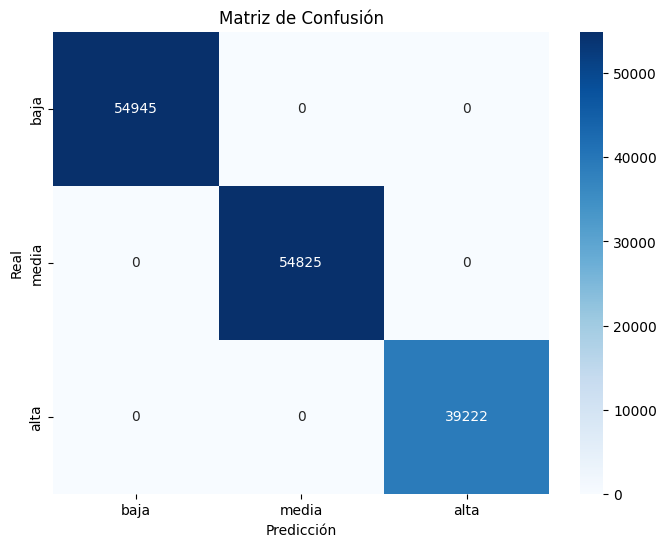

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['baja', 'media', 'alta'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['baja', 'media', 'alta'],
            yticklabels=['baja', 'media', 'alta'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


### Importancia de las características:

Por último, vamos a ver como de importantes son las características entre ellas para ver cuales son más importantes o influyentes que las demás.

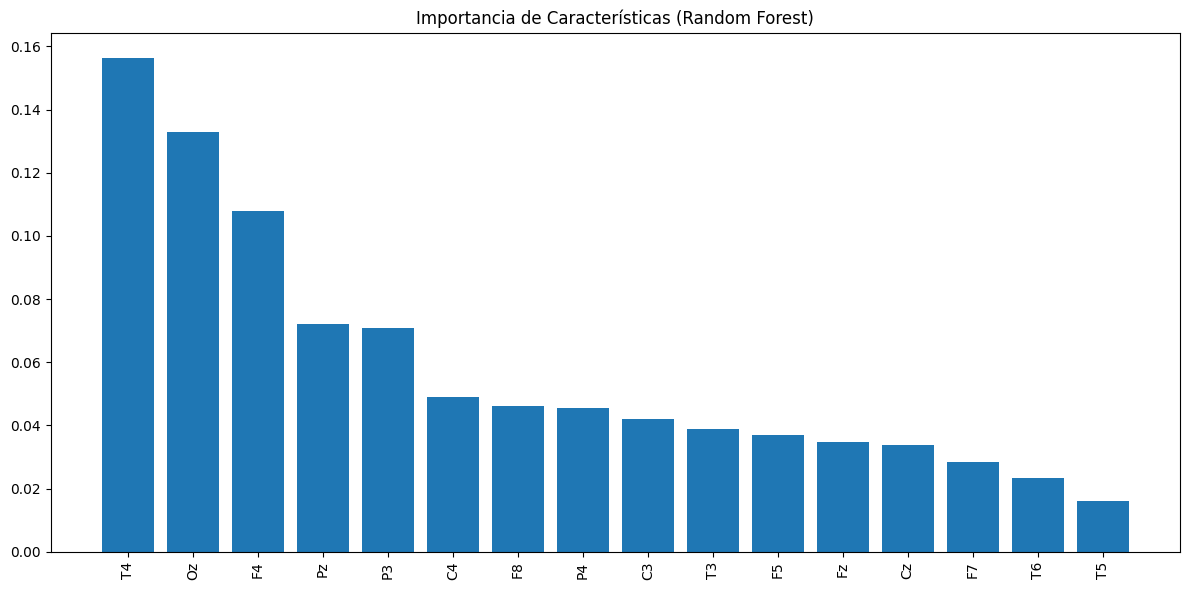

In [30]:
import numpy as np
import matplotlib.pyplot as plt

importances = clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

filtered_indices = [i for i in indices if 'Unnamed' not in features[i]]

plt.figure(figsize=(12, 6))
plt.title("Importancia de Características (Random Forest)")
plt.bar(range(len(filtered_indices)), importances[filtered_indices], align="center")
plt.xticks(range(len(filtered_indices)), [features[i] for i in filtered_indices], rotation=90)
plt.tight_layout()
plt.show()


## Conclusión:

Con este trabajo hemos podido ver las diversas características y datos de la carga cognitiva, en el cual las hemos clasificado, hemos realizado el ventaneo usando ventanas deslizantes, hemos realizado un análisis de las diversas caracteristicas, hemos visto cuales eran las más importantes de todas, hemos realizado un análisis por medio de Random Forest y por último hemos podido visualizar todo lo que hemos realizado con anterioridad.